In [1]:
## Load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wordcloud # For text visualization
from sklearn.preprocessing import  LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.utils import to_categorical
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from tqdm import tqdm
# from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoConfig, TFAutoModel

import warnings
warnings.filterwarnings('ignore')

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
print("✔️ CUDA:", tf.test.is_built_with_cuda())
print("✔️ cuDNN:", tf.test.is_built_with_gpu_support())
print("✔️ GPU devices:", tf.test.gpu_device_name())

✔️ CUDA: True
✔️ cuDNN: True
✔️ GPU devices: /device:GPU:0


In [4]:
# Load data
# file_path = '/content/drive/MyDrive/data/pqhs416_2025.csv'
file_path = "pqhs416_2025.csv"
df = pd.read_csv(file_path, index_col='ID')
df.index = df.index.astype(int)
df.index.name = None
# Preview the data
df.head()

,MRI,Microscopy,Immunohistochemistry,Localization,Diagnosis
2,0,"Glio-neuronal tumor, Microglia, Macrophage","Ki-67-positive, Ki-67-positive (10%)",temporo-occipital,Ganglioglioma WHO grade I
3,0,"Cellular tumor, mitosis, no necrosis","GFAP-positive, CD34-positive, MAP2-positive, K...",left temporo-polar,Atypical ganglioglioma WHO grade II
5,0,"small cell astroglial-like tumor, tumor with m...","Ki-67-positive, CD34-positive, Chromogranin A-...",right temporal lobe,Ganglioglioma WHO grade I
6,0,"Glial tumor cell, macrophage, microglial","GFAP-positive, CD34-positive, CD68-positive, K...","Temporo-occipital, Anterior temporal",Ganglioglioma WHO grade I
7,0,"Glio-neuronal tumor, focal microcalcification,...","GFAP-positive, MAP2-positive, Ki-67-positive, ...",0,Dysembryoplastic neuroepithelial tumor WHO Gra...


In [5]:
# Load ontology data
file_path = 'input_modified.csv'
ontology = pd.read_csv(file_path, index_col='ID')
ontology.index = ontology.index.astype(int)
ontology.index.name = None
# Set NaN values to 0
ontology.fillna(0, inplace=True)
# Preview the data
ontology.head()

,MRI,Microscopy,Immunohistochemistry,Localization,Diagnosis
2,0,"Glioneuronaltumor, Microglia, Macrophage",ki67-positive,TemporoOccipital,GangliogliomaWHOGradeI
3,0,"Cellulartumor, Mitosis, No Necrosis","cd34-positive, gfap-positive, idh1-positive, k...",Left TemporoPolar,AtypicalGangliogliomaWHOGradeIi
5,0,"Smallcellastrogialliketumor, Moderate Tumorcel...","cd34-positive, chromogranin-a-positive, ki67-p...",Right TemporalLobe,GangliogliomaWHOGradeI
6,0,"Glioma, Macrophage, Microglia","cd34-positive, cd68-positive, gfap-positive, k...","TemporoOccipital, AnteriorTemporal",GangliogliomaWHOGradeI
7,0,"Glioneuronaltumor, Microcalcification, Multino...","cd34-positive, cd68-positive, gfap-positive, k...",0,DysembryoplasticNeuroepithelialTumorWHOGradeI


## EDA

In [6]:
# Diagnosis distribution
df['Diagnosis'].value_counts()

Diagnosis
Focal Cortical Dysplasia Type IIb                     34
Ganglioglioma WHO grade I                             29
Hippocampal sclerosis Type I                          26
Mild malformation of cortical development             20
Mild Malformation of Cortical Development Type II     17
Dysembryoplastic neuroepithelial tumor WHO Grade I    10
Focal Cortical Dysplasia Type Ib                      10
No Hippocampal sclerosis                               8
Atypical ganglioglioma WHO grade II                    7
Focal cortical dysplasia Type IIId                     7
glial scarring                                         5
Pilocytic astrocytoma WHO grade I                      5
Name: count, dtype: int64

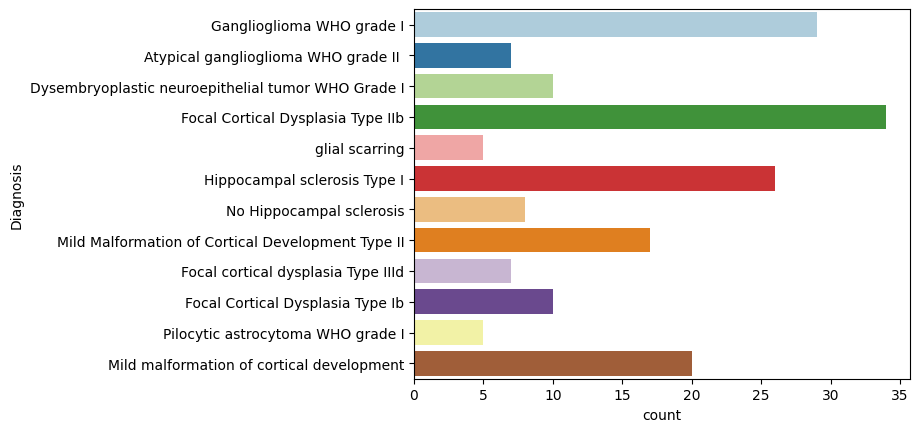

In [7]:
sns.countplot(y=df['Diagnosis'], palette="Paired")
plt.show()

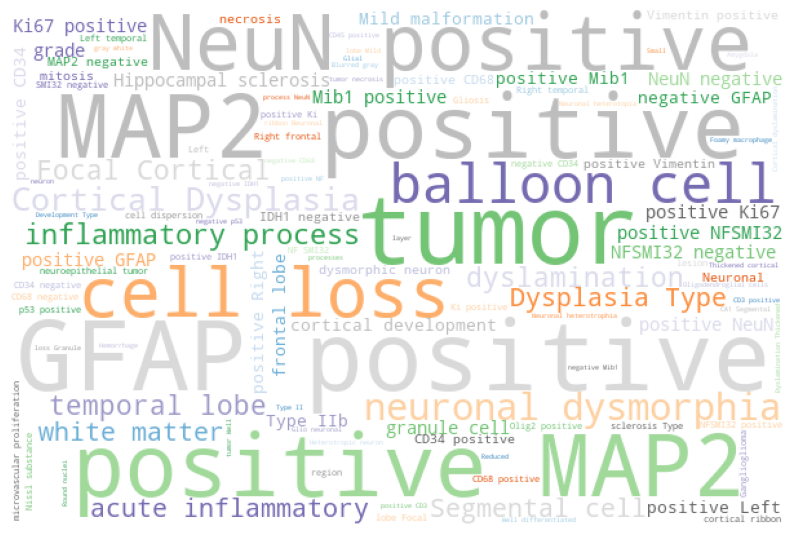

In [8]:
text_df = df.select_dtypes(include='object').replace('0', '')
all_text = ' '.join(text_df.fillna('').astype(str).values.flatten())
wordcloud_notes = wordcloud.WordCloud(stopwords=wordcloud.STOPWORDS, max_font_size=120, max_words=5000,
                      width = 600, height = 400, colormap = "tab20c",
                      background_color='white').generate(all_text)
fig, ax = plt.subplots(figsize=(10,8))
ax.imshow(wordcloud_notes, interpolation='bilinear')
ax.set_axis_off()
plt.imshow(wordcloud_notes);

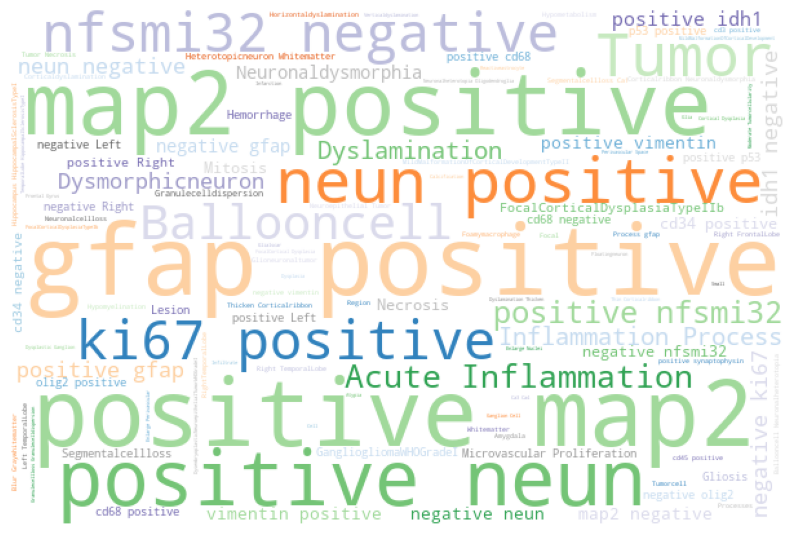

In [9]:
text_df = ontology.select_dtypes(include='object').replace('0', '')
all_text = ' '.join(text_df.fillna('').astype(str).values.flatten())
wordcloud_notes = wordcloud.WordCloud(stopwords=wordcloud.STOPWORDS, max_font_size=120, max_words=5000,
                      width = 600, height = 400, colormap = "tab20c",
                      background_color='white').generate(all_text)
fig, ax = plt.subplots(figsize=(10,8))
ax.imshow(wordcloud_notes, interpolation='bilinear')
ax.set_axis_off()
plt.imshow(wordcloud_notes);

## Config

In [10]:
# ---------- Model ----------
MODEL_NAME = 'Charangan/MedBERT'
MAX_LEN = 165

# ---------- Training ----------
BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 2e-5
CLIP_NORM = 1000


# ---------- Dataset ----------
RANDOM_STATE = 42
n_fold = 5
N_CLASS = np.unique(df['Diagnosis']).shape[0]

TRAIN = True
debug = False
if debug:
    EPOCHS = 3

## Data preprocessing

In [11]:
text_columns = ['MRI', 'Microscopy', 'Immunohistochemistry', 'Localization']
df[text_columns] = df[text_columns].replace("0", "").fillna("")

df["text"] = df[text_columns].astype(str).agg(" ".join, axis=1)

In [12]:
# for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
#     print(f"Fold {fold + 1}")
#     print(f"Train size: {len(train_idx)}")
#     print(f"Test size: {len(test_idx)}")
#     print("Test label distribution:")
#     print(y.iloc[test_idx].value_counts().sort_index())
#     print("-" * 30)

In [13]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Diagnosis'])
labels = to_categorical(df['label'])
class_names = le.classes_.tolist()

In [14]:
train_val_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=RANDOM_STATE)

In [15]:
skf = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=RANDOM_STATE)

## Transformer-based model


In [16]:
# Pre-trained Med-BERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
config = AutoConfig.from_pretrained(MODEL_NAME)
backbone = TFAutoModel.from_pretrained(MODEL_NAME, config=config, from_pt=True)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.5.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.dense.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.self.value.weight', 'bert.encoder.layer.11.attention.self.value.bias', 'cls.seq_relationship.weight', 'bert.encoder.layer.10.output.LayerNorm.bias', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.4.attention.self.query.weight', 'bert.encoder.layer.1.attention.self.query.bias', 'bert.encoder.layer.2.output.dense.bias', 'bert.encoder.layer.6.attention.self.query.bias', 'bert.encoder.layer.5.output.dense.bias', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.7.attention.self.value.weight', 'bert.encoder.layer.3.attention.output.dense.weight', 'bert.encoder.layer.4.attention.self.key.weight', 'bert.encoder.layer.11.a

In [17]:
# sample_texts = X.astype(str).agg(" ".join, axis=1).tolist()
# token_lens = [len(tokenizer(text)['input_ids']) for text in sample_texts]

# plt.hist(token_lens, bins=20)
# plt.title("Token Lengths per Sample")
# plt.xlabel("Length")
# plt.ylabel("Count")
# plt.show()

In [18]:
# Prepare tokenized input
tokens = tokenizer(
    df["text"].tolist(),
    padding='max_length',
    truncation=True,
    max_length=MAX_LEN,
    add_special_tokens=True,
    return_tensors='np'
)

input_ids = tokens['input_ids']
attention_mask = tokens["attention_mask"]

In [19]:
def build_model():
    input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
    attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

    outputs = backbone(input_ids=input_ids, attention_mask=attention_mask)
    # cls_token = outputs.last_hidden_state[:, 0, :]
    cls_token = outputs.pooler_output

    x = tf.keras.layers.Dropout(0.2)(cls_token)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dense(N_CLASS, activation='softmax')(x)

    model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=x)
    return model

In [20]:
model = build_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 165)]        0           []                               
                                                                                                  
 attention_mask (InputLayer)    [(None, 165)]        0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  108310272   ['input_ids[0][0]',              
                                thPoolingAndCrossAt               'attention_mask[0][0]']         
                                tentions(last_hidde                                               
                                n_state=(None, 165,                                           

In [21]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', mode='min', patience=3)

model.compile(
    optimizer = tf.keras.optimizers.Adam(LEARNING_RATE, clipnorm=CLIP_NORM),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
def plot_history(history):
    acc = history.history.get("accuracy")
    val_acc = history.history.get("val_accuracy")
    loss = history.history.get("loss")
    val_loss = history.history.get("val_loss")
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, '--', label='Training Accuracy')
    if val_acc:
        plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, '--', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


 Fold 1
Epoch 1/20
15/15 [==============================] - 17s 318ms/step - loss: 2.5107 - accuracy: 0.1504 - val_loss: 2.5031 - val_accuracy: 0.1379
Epoch 2/20
15/15 [==============================] - 3s 179ms/step - loss: 2.3663 - accuracy: 0.1062 - val_loss: 2.4677 - val_accuracy: 0.1034
Epoch 3/20
15/15 [==============================] - 3s 179ms/step - loss: 2.3172 - accuracy: 0.2035 - val_loss: 2.5761 - val_accuracy: 0.1379
Epoch 4/20
15/15 [==============================] - 3s 179ms/step - loss: 2.3370 - accuracy: 0.1947 - val_loss: 2.5117 - val_accuracy: 0.1724
Epoch 5/20
15/15 [==============================] - 3s 180ms/step - loss: 2.2969 - accuracy: 0.1239 - val_loss: 2.5824 - val_accuracy: 0.1379
Epoch 6/20
15/15 [==============================] - 3s 182ms/step - loss: 2.2335 - accuracy: 0.1947 - val_loss: 2.5216 - val_accuracy: 0.1379
Epoch 7/20
15/15 [==============================] - 3s 183ms/step - loss: 2.2133 - accuracy: 0.2389 - val_loss: 2.5238 - val_accuracy: 0.1

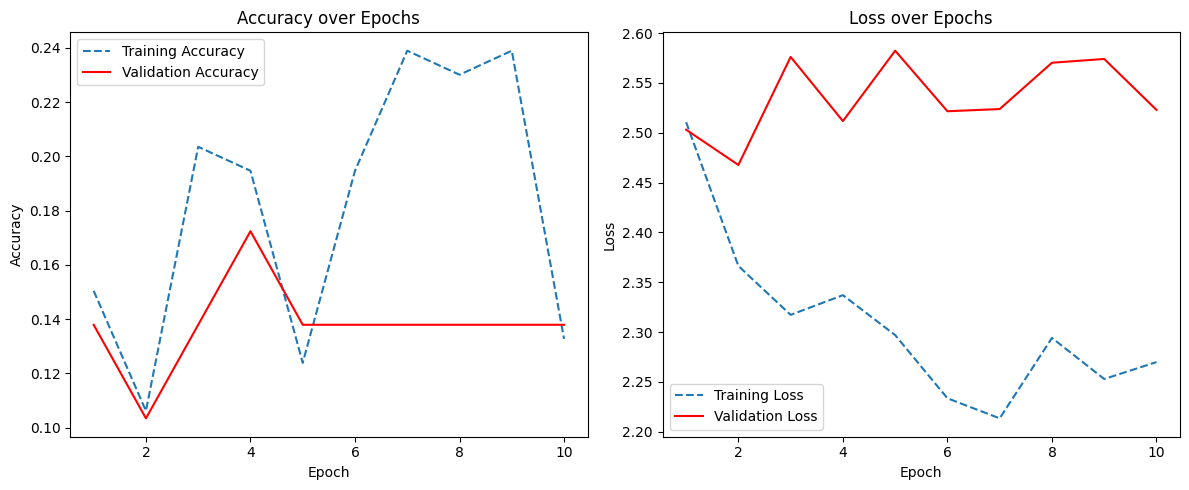


 Fold 2
Epoch 1/20
15/15 [==============================] - 3s 181ms/step - loss: 2.3491 - accuracy: 0.1593 - val_loss: 2.1680 - val_accuracy: 0.3103
Epoch 2/20
15/15 [==============================] - 3s 179ms/step - loss: 2.3476 - accuracy: 0.1327 - val_loss: 2.1659 - val_accuracy: 0.2414
Epoch 3/20
15/15 [==============================] - 3s 177ms/step - loss: 2.3602 - accuracy: 0.1947 - val_loss: 2.1445 - val_accuracy: 0.4138
Epoch 4/20
15/15 [==============================] - 3s 179ms/step - loss: 2.3213 - accuracy: 0.1770 - val_loss: 2.1380 - val_accuracy: 0.3793
Epoch 5/20
15/15 [==============================] - 3s 179ms/step - loss: 2.3509 - accuracy: 0.2035 - val_loss: 2.2182 - val_accuracy: 0.1034
Epoch 6/20
15/15 [==============================] - 3s 179ms/step - loss: 2.3038 - accuracy: 0.1593 - val_loss: 2.1300 - val_accuracy: 0.2414
Epoch 7/20
15/15 [==============================] - 3s 178ms/step - loss: 2.1865 - accuracy: 0.2389 - val_loss: 2.0383 - val_accuracy: 0.51

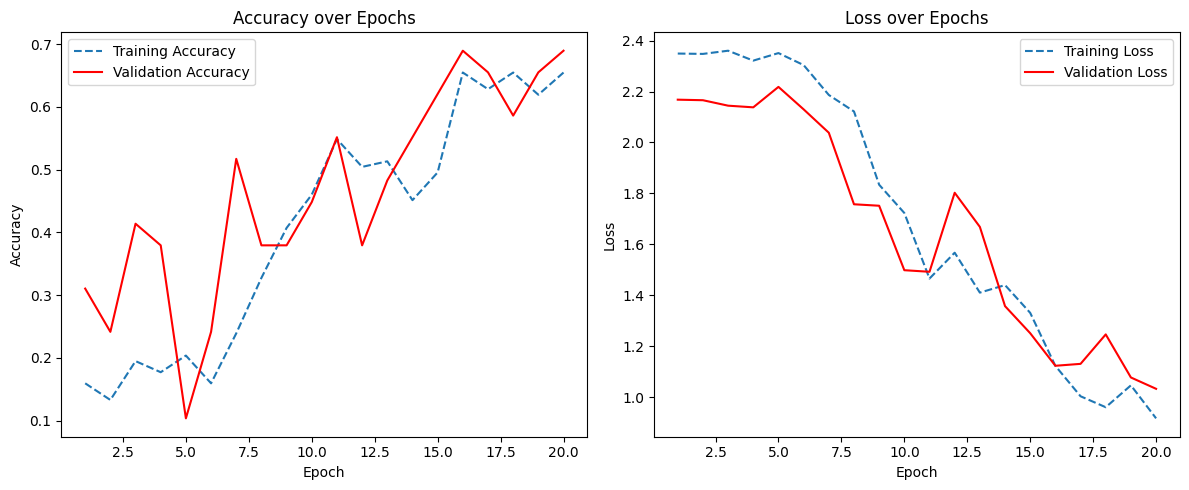


 Fold 3
Epoch 1/20
15/15 [==============================] - 3s 184ms/step - loss: 0.8164 - accuracy: 0.7193 - val_loss: 0.8064 - val_accuracy: 0.6786
Epoch 2/20
15/15 [==============================] - 3s 182ms/step - loss: 0.8005 - accuracy: 0.7193 - val_loss: 0.5535 - val_accuracy: 0.8214
Epoch 3/20
15/15 [==============================] - 3s 182ms/step - loss: 0.7072 - accuracy: 0.7632 - val_loss: 0.5549 - val_accuracy: 0.8214
Epoch 4/20
15/15 [==============================] - 3s 182ms/step - loss: 0.7400 - accuracy: 0.7281 - val_loss: 0.9739 - val_accuracy: 0.6786
Epoch 5/20
15/15 [==============================] - 3s 182ms/step - loss: 0.7469 - accuracy: 0.7193 - val_loss: 0.9985 - val_accuracy: 0.6786
Epoch 6/20
15/15 [==============================] - 3s 182ms/step - loss: 0.5984 - accuracy: 0.8246 - val_loss: 0.6610 - val_accuracy: 0.7857
Epoch 7/20
15/15 [==============================] - 3s 184ms/step - loss: 0.5856 - accuracy: 0.7982 - val_loss: 0.8573 - val_accuracy: 0.71

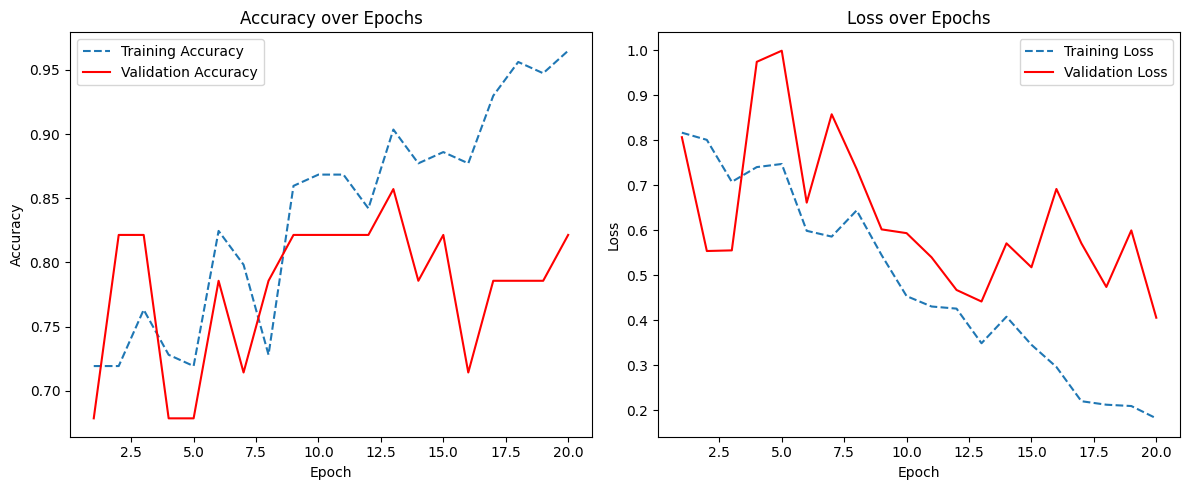


 Fold 4
Epoch 1/20
15/15 [==============================] - 3s 184ms/step - loss: 0.2311 - accuracy: 0.9035 - val_loss: 0.1848 - val_accuracy: 0.9286
Epoch 2/20
15/15 [==============================] - 3s 180ms/step - loss: 0.2108 - accuracy: 0.9298 - val_loss: 0.8073 - val_accuracy: 0.6786
Epoch 3/20
15/15 [==============================] - 3s 181ms/step - loss: 0.3438 - accuracy: 0.8509 - val_loss: 0.7458 - val_accuracy: 0.7143
Epoch 4/20
15/15 [==============================] - 3s 180ms/step - loss: 0.3837 - accuracy: 0.8596 - val_loss: 0.2121 - val_accuracy: 0.9286
Epoch 5/20
15/15 [==============================] - 3s 181ms/step - loss: 0.1831 - accuracy: 0.9474 - val_loss: 0.1935 - val_accuracy: 0.9643
Epoch 6/20
15/15 [==============================] - 3s 180ms/step - loss: 0.1547 - accuracy: 0.9386 - val_loss: 0.1489 - val_accuracy: 0.9286
Epoch 7/20
15/15 [==============================] - 3s 179ms/step - loss: 0.1561 - accuracy: 0.9561 - val_loss: 0.1378 - val_accuracy: 0.89

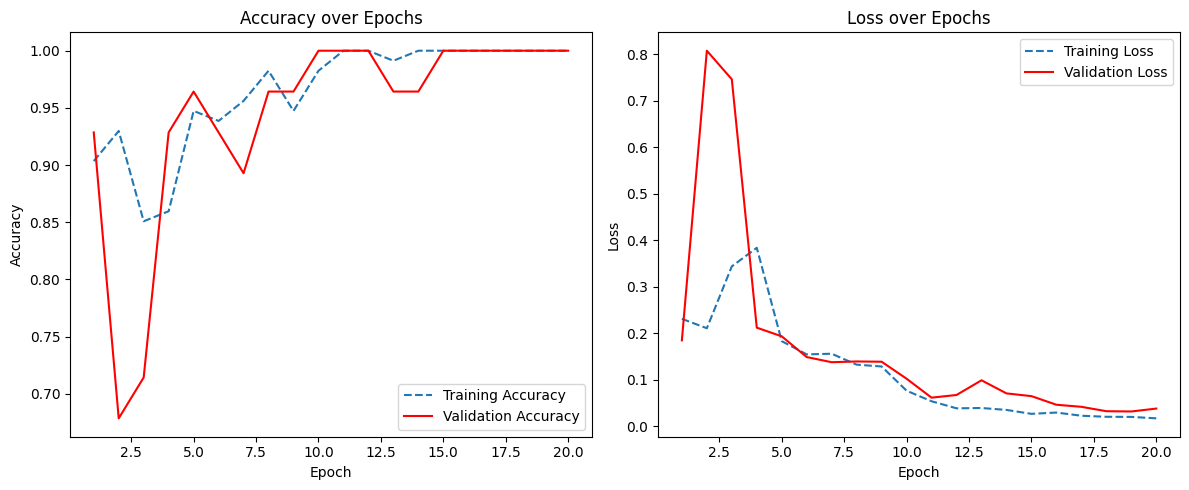


 Fold 5
Epoch 1/20
15/15 [==============================] - 3s 182ms/step - loss: 0.0239 - accuracy: 1.0000 - val_loss: 0.0089 - val_accuracy: 1.0000
Epoch 2/20
15/15 [==============================] - 3s 181ms/step - loss: 0.0234 - accuracy: 1.0000 - val_loss: 0.0083 - val_accuracy: 1.0000
Epoch 3/20
15/15 [==============================] - 3s 179ms/step - loss: 0.0276 - accuracy: 1.0000 - val_loss: 0.0078 - val_accuracy: 1.0000
Epoch 4/20
15/15 [==============================] - 3s 180ms/step - loss: 0.0248 - accuracy: 1.0000 - val_loss: 0.0160 - val_accuracy: 1.0000
Epoch 5/20
15/15 [==============================] - 3s 180ms/step - loss: 0.0324 - accuracy: 0.9912 - val_loss: 0.0461 - val_accuracy: 1.0000


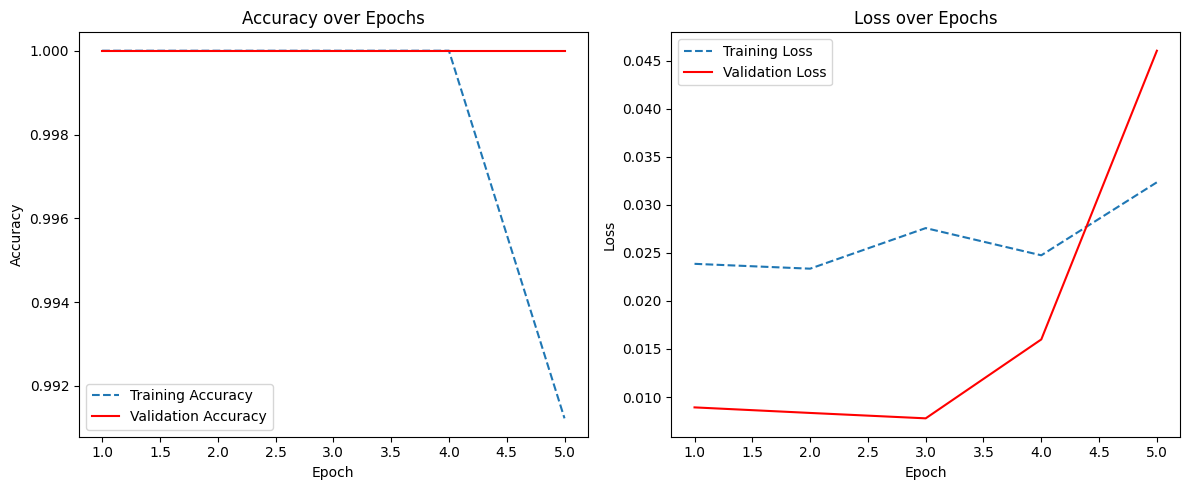

In [23]:
for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df["text"], train_val_df["label"])):
    print(f"\n Fold {fold + 1}")

    input_ids_train, input_ids_val = input_ids[train_idx], input_ids[val_idx]
    attention_mask_train, attention_mask_val = attention_mask[train_idx], attention_mask[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]
    # print(f"Train size: {len(train_idx)}")
    # print(f"Validation size: {len(val_idx)}")

    history = model.fit(
        x={"input_ids": input_ids_train, "attention_mask": attention_mask_train},
        y=y_train,
        validation_data=({"input_ids": input_ids_val, "attention_mask": attention_mask_val}, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[callback],
        shuffle=True,
        verbose=1
    )
    # Save model
    model.save_weights(f"fold_{fold + 1}.h5")

    plot_history(history)


In [24]:
def prediction(model, test_df):

    test_tokens = tokenizer(
        test_df["text"].tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=True,
        return_tensors='np'
    )

    input_ids = test_tokens["input_ids"]
    attention_mask = test_tokens["attention_mask"]

    # Predict
    pred = model.predict({"input_ids": input_ids, "attention_mask": attention_mask})
    return pred 

In [25]:
# Evaluate on test set
def evaluate_model(model, test_df, class_names = class_names):
    """
    Evaluate model performance on test set and print metrics.
    """

    y_pred = np.argmax(prediction(model, test_df), axis=1)
    y_true = test_df['label'].values

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"Test Acc: {acc:.4f}\n")

    # Classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                square=True, xticklabels=class_names, yticklabels=class_names)
    plt.xticks(fontsize=5)
    plt.yticks(fontsize=5) 
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()



 Evaluating Fold 1 Model
2/2 [==============================] - 2s 38ms/step
Test Acc: 0.1944

Classification Report:
                                                    precision    recall  f1-score   support

              Atypical ganglioglioma WHO grade II        0.00      0.00      0.00         1
Dysembryoplastic neuroepithelial tumor WHO Grade I       0.00      0.00      0.00         2
                 Focal Cortical Dysplasia Type IIb       0.19      1.00      0.33         7
                  Focal Cortical Dysplasia Type Ib       0.00      0.00      0.00         2
                Focal cortical dysplasia Type IIId       0.00      0.00      0.00         1
                         Ganglioglioma WHO grade I       0.00      0.00      0.00         6
                      Hippocampal sclerosis Type I       0.00      0.00      0.00         5
 Mild Malformation of Cortical Development Type II       0.00      0.00      0.00         4
         Mild malformation of cortical development  

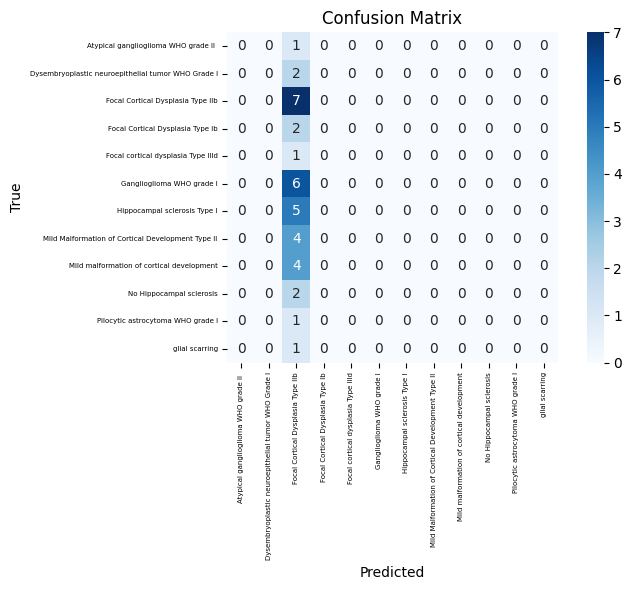


 Evaluating Fold 2 Model
2/2 [==============================] - 2s 51ms/step
Test Acc: 0.7222

Classification Report:
                                                    precision    recall  f1-score   support

              Atypical ganglioglioma WHO grade II        0.00      0.00      0.00         1
Dysembryoplastic neuroepithelial tumor WHO Grade I       1.00      0.50      0.67         2
                 Focal Cortical Dysplasia Type IIb       1.00      0.86      0.92         7
                  Focal Cortical Dysplasia Type Ib       0.67      1.00      0.80         2
                Focal cortical dysplasia Type IIId       0.00      0.00      0.00         1
                         Ganglioglioma WHO grade I       0.60      1.00      0.75         6
                      Hippocampal sclerosis Type I       0.83      1.00      0.91         5
 Mild Malformation of Cortical Development Type II       0.50      0.75      0.60         4
         Mild malformation of cortical development  

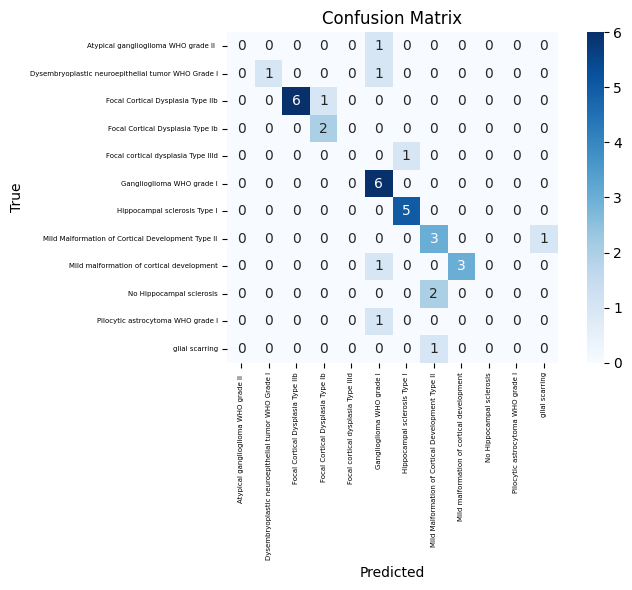


 Evaluating Fold 3 Model
2/2 [==============================] - 2s 35ms/step
Test Acc: 0.8611

Classification Report:
                                                    precision    recall  f1-score   support

              Atypical ganglioglioma WHO grade II        0.00      0.00      0.00         1
Dysembryoplastic neuroepithelial tumor WHO Grade I       0.50      1.00      0.67         2
                 Focal Cortical Dysplasia Type IIb       1.00      0.86      0.92         7
                  Focal Cortical Dysplasia Type Ib       1.00      1.00      1.00         2
                Focal cortical dysplasia Type IIId       0.00      0.00      0.00         1
                         Ganglioglioma WHO grade I       1.00      0.83      0.91         6
                      Hippocampal sclerosis Type I       1.00      1.00      1.00         5
 Mild Malformation of Cortical Development Type II       0.80      1.00      0.89         4
         Mild malformation of cortical development  

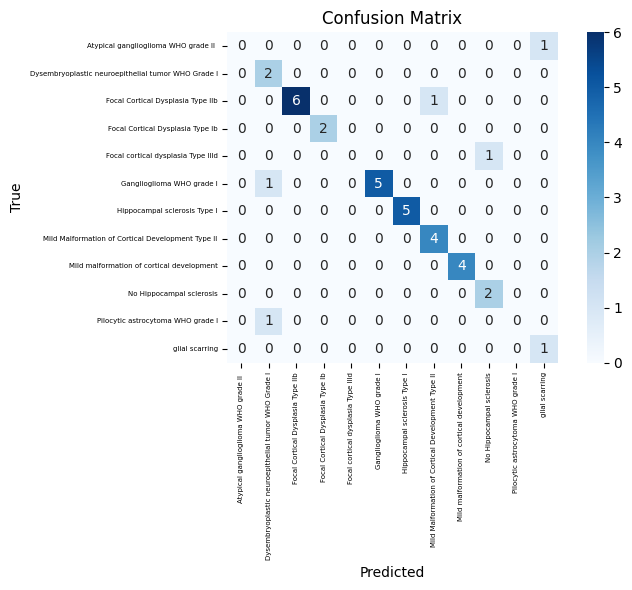


 Evaluating Fold 4 Model
2/2 [==============================] - 2s 54ms/step
Test Acc: 0.8333

Classification Report:
                                                    precision    recall  f1-score   support

              Atypical ganglioglioma WHO grade II        0.00      0.00      0.00         1
Dysembryoplastic neuroepithelial tumor WHO Grade I       0.67      1.00      0.80         2
                 Focal Cortical Dysplasia Type IIb       1.00      0.86      0.92         7
                  Focal Cortical Dysplasia Type Ib       1.00      1.00      1.00         2
                Focal cortical dysplasia Type IIId       0.00      0.00      0.00         1
                         Ganglioglioma WHO grade I       0.83      0.83      0.83         6
                      Hippocampal sclerosis Type I       0.83      1.00      0.91         5
 Mild Malformation of Cortical Development Type II       0.67      1.00      0.80         4
         Mild malformation of cortical development  

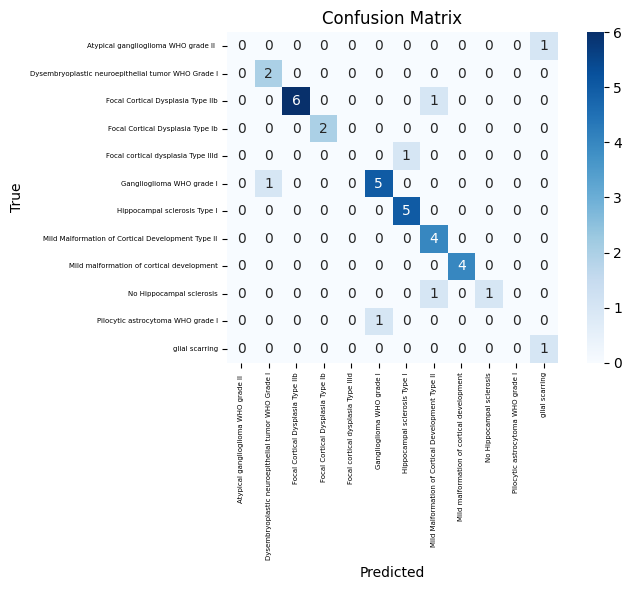


 Evaluating Fold 5 Model
2/2 [==============================] - 2s 43ms/step
Test Acc: 0.8611

Classification Report:
                                                    precision    recall  f1-score   support

              Atypical ganglioglioma WHO grade II        0.00      0.00      0.00         1
Dysembryoplastic neuroepithelial tumor WHO Grade I       0.67      1.00      0.80         2
                 Focal Cortical Dysplasia Type IIb       1.00      0.86      0.92         7
                  Focal Cortical Dysplasia Type Ib       1.00      1.00      1.00         2
                Focal cortical dysplasia Type IIId       0.00      0.00      0.00         1
                         Ganglioglioma WHO grade I       0.83      0.83      0.83         6
                      Hippocampal sclerosis Type I       1.00      1.00      1.00         5
 Mild Malformation of Cortical Development Type II       0.80      1.00      0.89         4
         Mild malformation of cortical development  

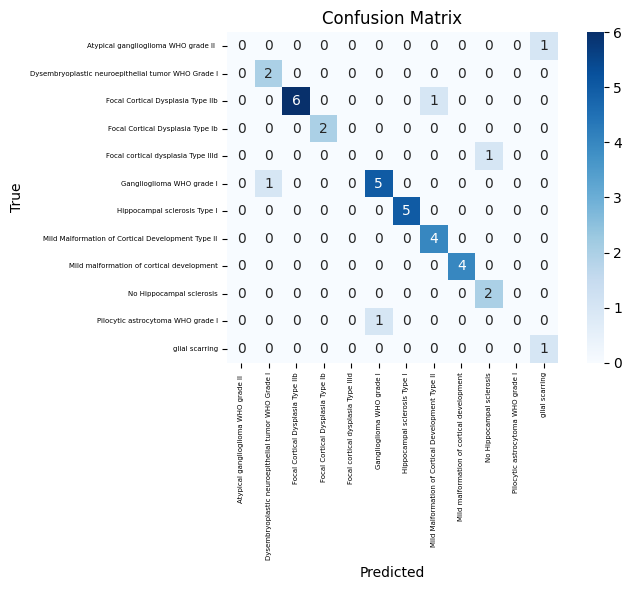

In [26]:
for fold in range(1, 6):
    print(f"\n Evaluating Fold {fold} Model")
    
    model = build_model()
    model.load_weights(f"fold_{fold}.h5")

    evaluate_model(model=model,test_df=test_df, class_names=class_names)


In [27]:
# Ensemble methods
preds = []
for fold in range(1, 6):
    
    model = build_model()
    model.load_weights(f"fold_{fold}.h5")

    pred = prediction(model=model,test_df=test_df)
    preds.append(pred) 

2/2 [==============================] - 2s 50ms/step


In [28]:
avg_preds = np.mean(np.array(preds), axis=0)
y_pred = np.argmax(avg_preds, axis=1)

Test Acc: 0.8333

Classification Report:
                                                    precision    recall  f1-score   support

              Atypical ganglioglioma WHO grade II        0.00      0.00      0.00         1
Dysembryoplastic neuroepithelial tumor WHO Grade I       0.67      1.00      0.80         2
                 Focal Cortical Dysplasia Type IIb       1.00      0.86      0.92         7
                  Focal Cortical Dysplasia Type Ib       1.00      1.00      1.00         2
                Focal cortical dysplasia Type IIId       0.00      0.00      0.00         1
                         Ganglioglioma WHO grade I       0.83      0.83      0.83         6
                      Hippocampal sclerosis Type I       1.00      1.00      1.00         5
 Mild Malformation of Cortical Development Type II       0.67      1.00      0.80         4
         Mild malformation of cortical development       1.00      1.00      1.00         4
                          No Hippocamp

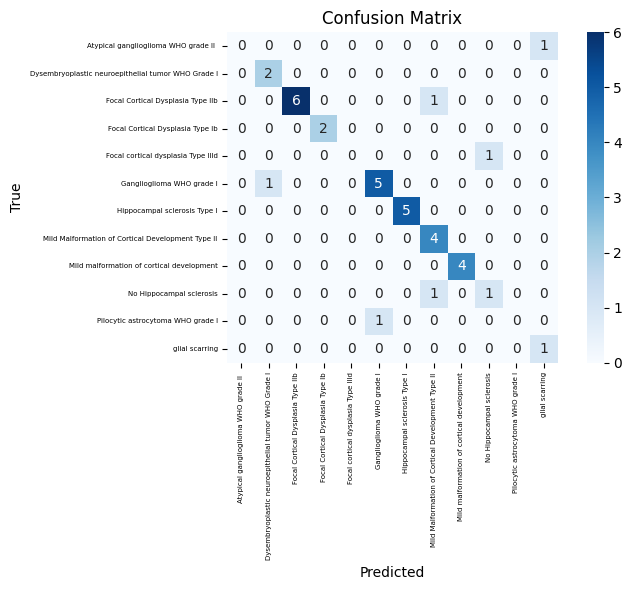

In [29]:
y_true = test_df['label'].values

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test Acc: {acc:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            square=True, xticklabels=class_names, yticklabels=class_names)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5) 
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [30]:
preds = []
for fold in range(1, 6):
    
    model = build_model()
    model.load_weights(f"fold_{fold}.h5")

    pred = prediction(model=model,test_df=train_val_df)
    preds.append(pred) 

avg_preds = np.mean(np.array(preds), axis=0)
y_pred = np.argmax(avg_preds, axis=1)

5/5 [==============================] - 3s 176ms/step


Test Acc: 0.9085

Classification Report:
                                                    precision    recall  f1-score   support

              Atypical ganglioglioma WHO grade II        1.00      0.83      0.91         6
Dysembryoplastic neuroepithelial tumor WHO Grade I       0.73      1.00      0.84         8
                 Focal Cortical Dysplasia Type IIb       0.96      0.96      0.96        27
                  Focal Cortical Dysplasia Type Ib       0.80      1.00      0.89         8
                Focal cortical dysplasia Type IIId       1.00      0.67      0.80         6
                         Ganglioglioma WHO grade I       0.86      0.83      0.84        23
                      Hippocampal sclerosis Type I       1.00      0.95      0.98        21
 Mild Malformation of Cortical Development Type II       1.00      0.85      0.92        13
         Mild malformation of cortical development       0.89      1.00      0.94        16
                          No Hippocamp

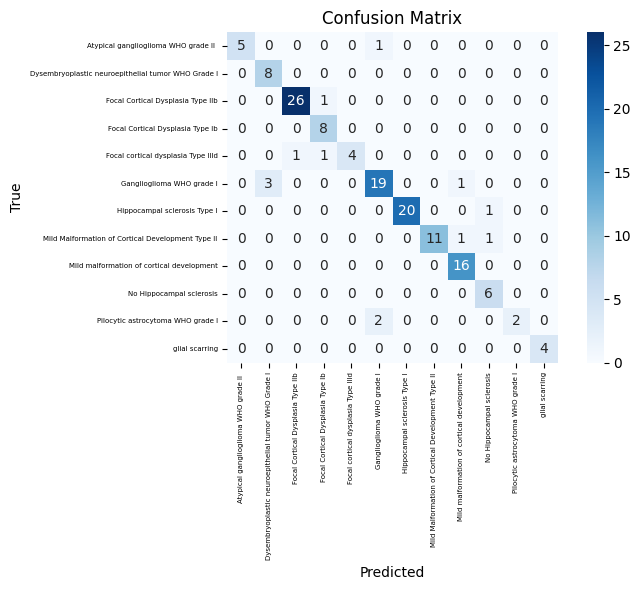

In [31]:
y_true = train_val_df['label'].values

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test Acc: {acc:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            square=True, xticklabels=class_names, yticklabels=class_names)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5) 
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Add Ontology feature

In [32]:
text_columns = ['MRI', 'Microscopy', 'Immunohistochemistry', 'Localization']
ontology[text_columns] = ontology[text_columns].replace("0", "").fillna("")

ontology["text"] = ontology[text_columns].astype(str).agg(" ".join, axis=1)

In [33]:
le = LabelEncoder()
ontology['label'] = le.fit_transform(ontology['Diagnosis'])
labels = to_categorical(ontology['label'])
class_names = le.classes_.tolist()

In [34]:
train_val_ontology, test_ontology = train_test_split(ontology, test_size=0.2, stratify=ontology["label"], random_state=RANDOM_STATE)

In [35]:
skf = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=RANDOM_STATE)

In [36]:
# Pre-trained Med-BERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
config = AutoConfig.from_pretrained(MODEL_NAME)
backbone = TFAutoModel.from_pretrained(MODEL_NAME, config=config, from_pt=True)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.5.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.dense.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.self.value.weight', 'bert.encoder.layer.11.attention.self.value.bias', 'cls.seq_relationship.weight', 'bert.encoder.layer.10.output.LayerNorm.bias', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.4.attention.self.query.weight', 'bert.encoder.layer.1.attention.self.query.bias', 'bert.encoder.layer.2.output.dense.bias', 'bert.encoder.layer.6.attention.self.query.bias', 'bert.encoder.layer.5.output.dense.bias', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.7.attention.self.value.weight', 'bert.encoder.layer.3.attention.output.dense.weight', 'bert.encoder.layer.4.attention.self.key.weight', 'bert.encoder.layer.11.a

In [37]:
# Prepare tokenized input
tokens = tokenizer(
    ontology["text"].tolist(),
    padding='max_length',
    truncation=True,
    max_length=MAX_LEN,
    add_special_tokens=True,
    return_tensors='np'
)

input_ids = tokens['input_ids']
attention_mask = tokens["attention_mask"]

In [38]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', mode='min', patience=3)

model.compile(
    optimizer = tf.keras.optimizers.Adam(LEARNING_RATE, clipnorm=CLIP_NORM),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


 Fold 1
Epoch 1/20
15/15 [==============================] - 17s 314ms/step - loss: 2.7083 - accuracy: 0.3628 - val_loss: 1.6169 - val_accuracy: 0.5172
Epoch 2/20
15/15 [==============================] - 3s 179ms/step - loss: 1.4409 - accuracy: 0.5575 - val_loss: 1.5827 - val_accuracy: 0.4828
Epoch 3/20
15/15 [==============================] - 3s 180ms/step - loss: 1.1299 - accuracy: 0.6637 - val_loss: 1.5938 - val_accuracy: 0.5172
Epoch 4/20
15/15 [==============================] - 3s 180ms/step - loss: 1.3226 - accuracy: 0.5752 - val_loss: 1.1821 - val_accuracy: 0.5862
Epoch 5/20
15/15 [==============================] - 3s 181ms/step - loss: 1.0095 - accuracy: 0.6637 - val_loss: 1.1548 - val_accuracy: 0.5517
Epoch 6/20
15/15 [==============================] - 3s 182ms/step - loss: 0.8983 - accuracy: 0.6903 - val_loss: 1.1756 - val_accuracy: 0.5862
Epoch 7/20
15/15 [==============================] - 3s 182ms/step - loss: 0.7888 - accuracy: 0.7522 - val_loss: 1.2472 - val_accuracy: 0.5

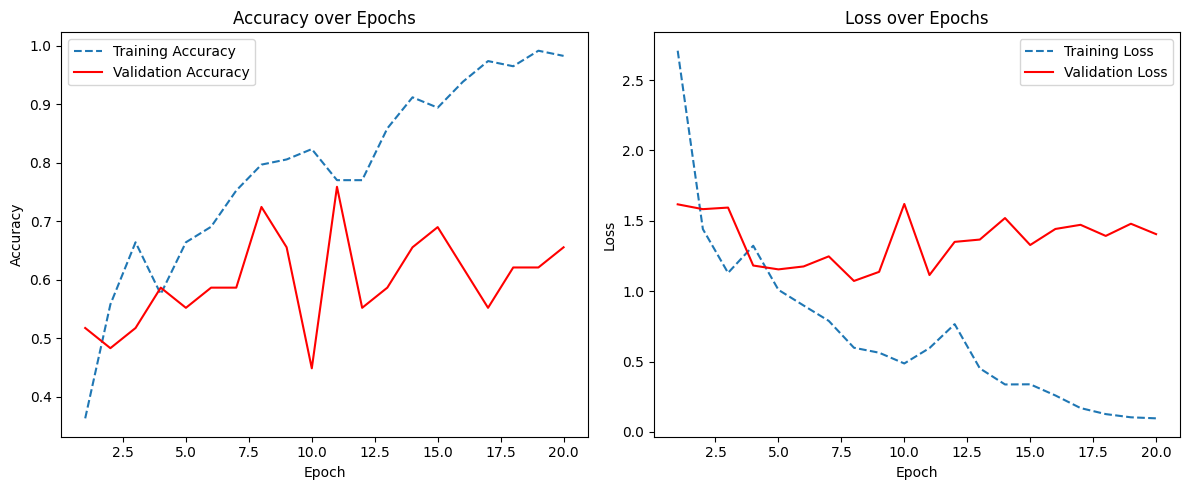


 Fold 2
Epoch 1/20
15/15 [==============================] - 3s 183ms/step - loss: 0.4867 - accuracy: 0.8850 - val_loss: 0.1514 - val_accuracy: 0.9655
Epoch 2/20
15/15 [==============================] - 3s 181ms/step - loss: 0.3909 - accuracy: 0.8938 - val_loss: 0.1832 - val_accuracy: 0.9310
Epoch 3/20
15/15 [==============================] - 3s 182ms/step - loss: 0.3018 - accuracy: 0.8673 - val_loss: 0.0802 - val_accuracy: 1.0000
Epoch 4/20
15/15 [==============================] - 3s 182ms/step - loss: 0.4137 - accuracy: 0.8584 - val_loss: 0.4772 - val_accuracy: 0.7931
Epoch 5/20
15/15 [==============================] - 3s 182ms/step - loss: 0.4041 - accuracy: 0.8938 - val_loss: 0.3238 - val_accuracy: 0.8966
Epoch 6/20
15/15 [==============================] - 3s 181ms/step - loss: 0.2874 - accuracy: 0.9381 - val_loss: 0.1059 - val_accuracy: 0.9655
Epoch 7/20
15/15 [==============================] - 3s 182ms/step - loss: 0.1781 - accuracy: 0.9469 - val_loss: 0.1116 - val_accuracy: 1.00

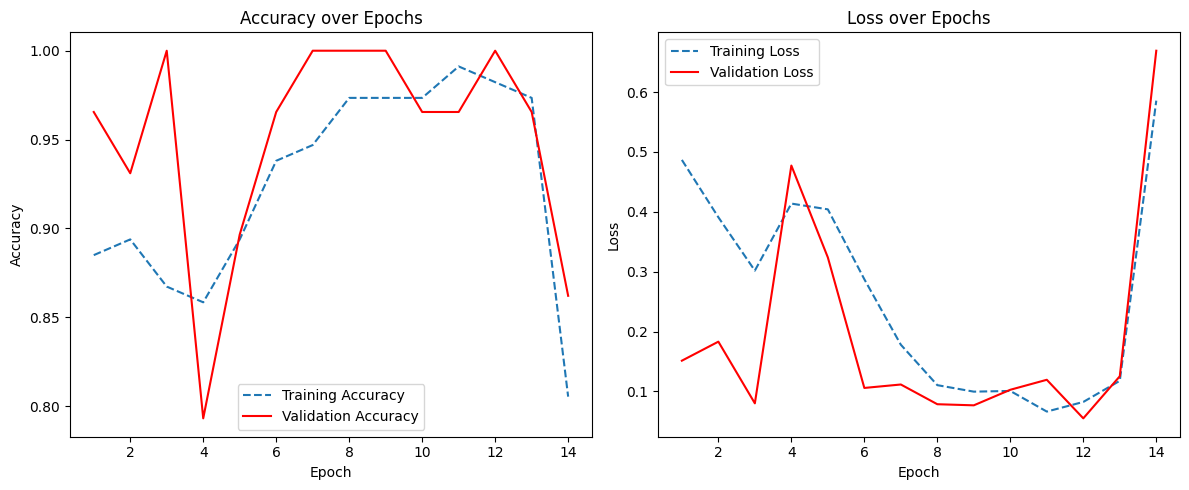


 Fold 3
Epoch 1/20
15/15 [==============================] - 3s 182ms/step - loss: 0.5892 - accuracy: 0.8158 - val_loss: 0.3149 - val_accuracy: 0.8571
Epoch 2/20
15/15 [==============================] - 3s 180ms/step - loss: 0.3810 - accuracy: 0.8684 - val_loss: 0.0959 - val_accuracy: 1.0000
Epoch 3/20
15/15 [==============================] - 3s 180ms/step - loss: 0.2011 - accuracy: 0.9561 - val_loss: 0.0476 - val_accuracy: 1.0000
Epoch 4/20
15/15 [==============================] - 3s 180ms/step - loss: 0.3882 - accuracy: 0.8684 - val_loss: 0.0711 - val_accuracy: 1.0000
Epoch 5/20
15/15 [==============================] - 3s 180ms/step - loss: 0.3450 - accuracy: 0.8772 - val_loss: 0.2234 - val_accuracy: 0.8929
Epoch 6/20
15/15 [==============================] - 3s 179ms/step - loss: 0.2467 - accuracy: 0.9211 - val_loss: 0.0812 - val_accuracy: 1.0000


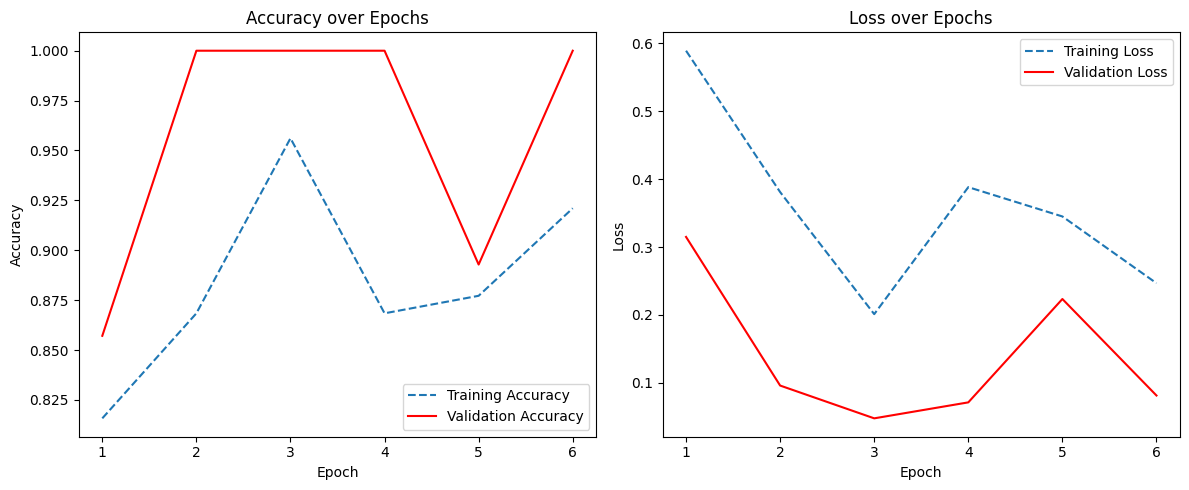


 Fold 4
Epoch 1/20
15/15 [==============================] - 3s 183ms/step - loss: 0.1475 - accuracy: 0.9649 - val_loss: 0.0767 - val_accuracy: 1.0000
Epoch 2/20
15/15 [==============================] - 3s 180ms/step - loss: 0.0725 - accuracy: 0.9912 - val_loss: 0.0949 - val_accuracy: 0.9643
Epoch 3/20
15/15 [==============================] - 3s 182ms/step - loss: 0.0563 - accuracy: 0.9912 - val_loss: 0.0925 - val_accuracy: 0.9643
Epoch 4/20
15/15 [==============================] - 3s 179ms/step - loss: 0.0431 - accuracy: 0.9912 - val_loss: 0.0778 - val_accuracy: 0.9643
Epoch 5/20
15/15 [==============================] - 3s 180ms/step - loss: 0.0394 - accuracy: 0.9912 - val_loss: 0.0733 - val_accuracy: 0.9643
Epoch 6/20
15/15 [==============================] - 3s 180ms/step - loss: 0.0276 - accuracy: 1.0000 - val_loss: 0.1067 - val_accuracy: 0.9643
Epoch 7/20
15/15 [==============================] - 3s 179ms/step - loss: 0.0281 - accuracy: 1.0000 - val_loss: 0.0778 - val_accuracy: 0.96

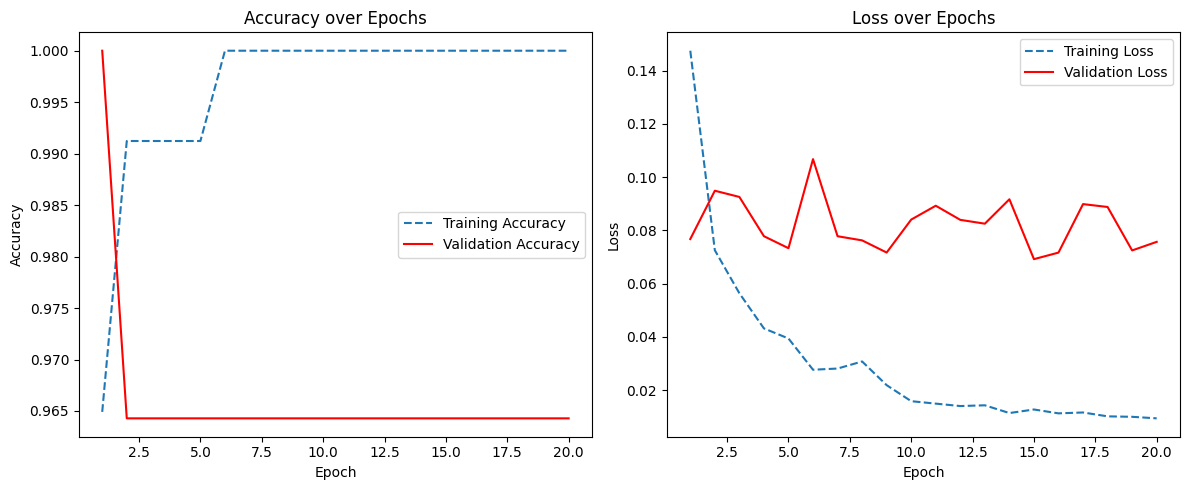


 Fold 5
Epoch 1/20
15/15 [==============================] - 3s 184ms/step - loss: 0.0216 - accuracy: 0.9912 - val_loss: 0.0065 - val_accuracy: 1.0000
Epoch 2/20
15/15 [==============================] - 3s 182ms/step - loss: 0.0125 - accuracy: 1.0000 - val_loss: 0.0036 - val_accuracy: 1.0000
Epoch 3/20
15/15 [==============================] - 3s 182ms/step - loss: 0.0122 - accuracy: 1.0000 - val_loss: 0.0035 - val_accuracy: 1.0000
Epoch 4/20
15/15 [==============================] - 3s 182ms/step - loss: 0.0085 - accuracy: 1.0000 - val_loss: 0.0039 - val_accuracy: 1.0000
Epoch 5/20
15/15 [==============================] - 3s 182ms/step - loss: 0.0080 - accuracy: 1.0000 - val_loss: 0.0035 - val_accuracy: 1.0000
Epoch 6/20
15/15 [==============================] - 3s 182ms/step - loss: 0.0085 - accuracy: 1.0000 - val_loss: 0.0033 - val_accuracy: 1.0000
Epoch 7/20
15/15 [==============================] - 3s 181ms/step - loss: 0.0075 - accuracy: 1.0000 - val_loss: 0.0037 - val_accuracy: 1.00

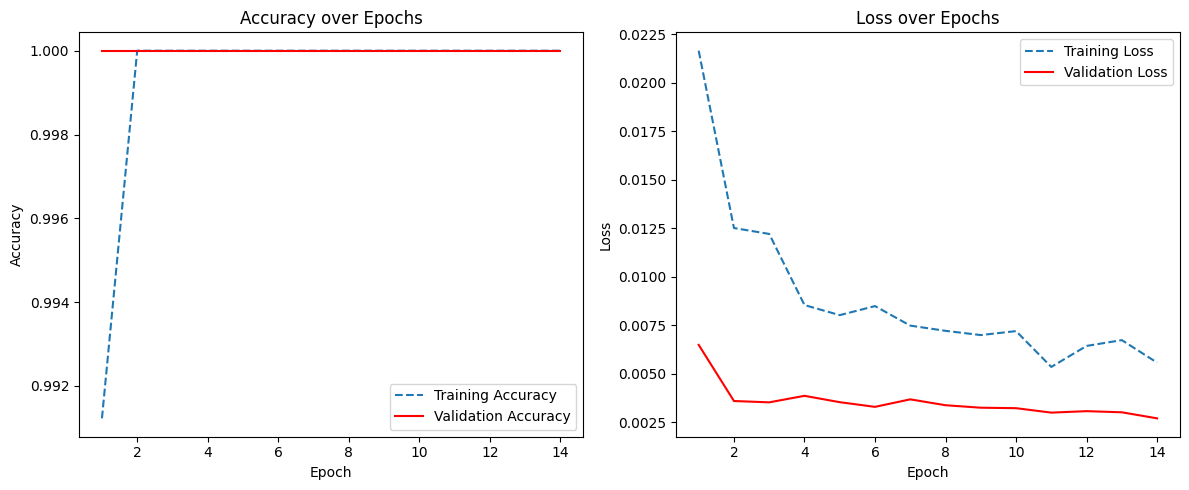

In [39]:
for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_ontology["text"], train_val_ontology["label"])):
    print(f"\n Fold {fold + 1}")

    input_ids_train, input_ids_val = input_ids[train_idx], input_ids[val_idx]
    attention_mask_train, attention_mask_val = attention_mask[train_idx], attention_mask[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]
    # print(f"Train size: {len(train_idx)}")
    # print(f"Validation size: {len(val_idx)}")

    history = model.fit(
        x={"input_ids": input_ids_train, "attention_mask": attention_mask_train},
        y=y_train,
        validation_data=({"input_ids": input_ids_val, "attention_mask": attention_mask_val}, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[callback],
        shuffle=True,
        verbose=1
    )
    # Save model
    model.save_weights(f"ontology_fold_{fold + 1}.h5")

    plot_history(history)


 Evaluating Fold 1 Model
2/2 [==============================] - 2s 35ms/step
Test Acc: 0.8056

Classification Report:
                                               precision    recall  f1-score   support

             AtypicalGangliogliomaWHOGradeIi        0.00      0.00      0.00         1
DysembryoplasticNeuroepithelialTumorWHOGradeI       1.00      1.00      1.00         2
               FocalCorticalDysplasiaTypeIIId       0.00      0.00      0.00         1
                FocalCorticalDysplasiaTypeIIb       1.00      0.71      0.83         7
                 FocalCorticalDysplasiaTypeIb       0.25      0.50      0.33         2
                       GangliogliomaWHOGradeI       0.86      1.00      0.92         6
                                GlialScarring       0.33      1.00      0.50         1
                    HippocampalSclerosisTypeI       1.00      1.00      1.00         5
        MildMalformationOfCorticalDevelopment       0.80      1.00      0.89         4
  MildMalf

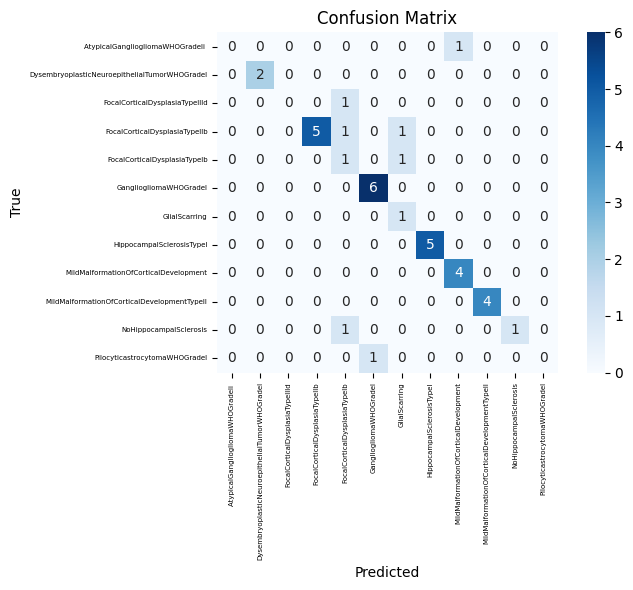


 Evaluating Fold 2 Model
2/2 [==============================] - 2s 39ms/step
Test Acc: 0.7778

Classification Report:
                                               precision    recall  f1-score   support

             AtypicalGangliogliomaWHOGradeIi        0.00      0.00      0.00         1
DysembryoplasticNeuroepithelialTumorWHOGradeI       1.00      1.00      1.00         2
               FocalCorticalDysplasiaTypeIIId       0.00      0.00      0.00         1
                FocalCorticalDysplasiaTypeIIb       1.00      0.86      0.92         7
                 FocalCorticalDysplasiaTypeIb       0.40      1.00      0.57         2
                       GangliogliomaWHOGradeI       0.86      1.00      0.92         6
                                GlialScarring       0.00      0.00      0.00         1
                    HippocampalSclerosisTypeI       0.71      1.00      0.83         5
        MildMalformationOfCorticalDevelopment       1.00      1.00      1.00         4
  MildMalf

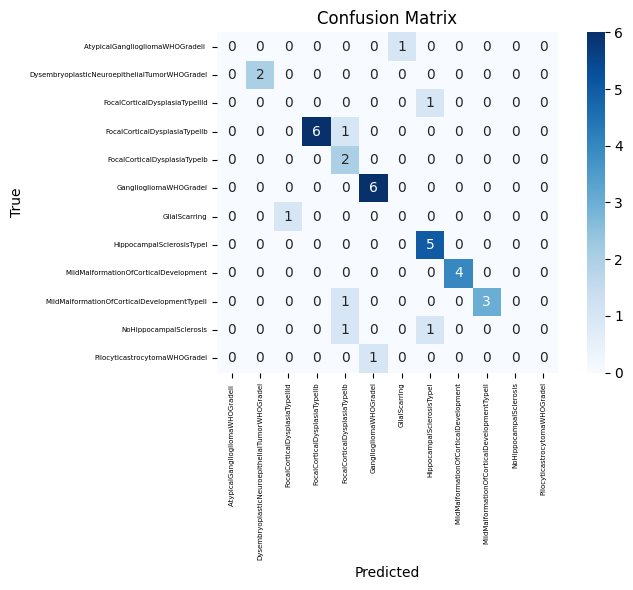


 Evaluating Fold 3 Model
2/2 [==============================] - 2s 35ms/step
Test Acc: 0.8611

Classification Report:
                                               precision    recall  f1-score   support

             AtypicalGangliogliomaWHOGradeIi        0.00      0.00      0.00         1
DysembryoplasticNeuroepithelialTumorWHOGradeI       1.00      1.00      1.00         2
               FocalCorticalDysplasiaTypeIIId       0.00      0.00      0.00         1
                FocalCorticalDysplasiaTypeIIb       1.00      0.71      0.83         7
                 FocalCorticalDysplasiaTypeIb       0.50      1.00      0.67         2
                       GangliogliomaWHOGradeI       1.00      1.00      1.00         6
                                GlialScarring       1.00      1.00      1.00         1
                    HippocampalSclerosisTypeI       1.00      1.00      1.00         5
        MildMalformationOfCorticalDevelopment       0.80      1.00      0.89         4
  MildMalf

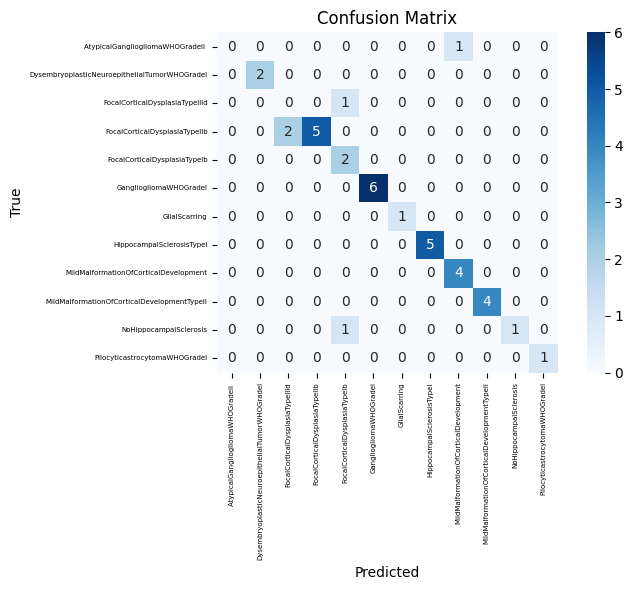


 Evaluating Fold 4 Model
2/2 [==============================] - 3s 40ms/step
Test Acc: 0.9444

Classification Report:
                                               precision    recall  f1-score   support

             AtypicalGangliogliomaWHOGradeIi        0.00      0.00      0.00         1
DysembryoplasticNeuroepithelialTumorWHOGradeI       1.00      1.00      1.00         2
               FocalCorticalDysplasiaTypeIIId       0.00      0.00      0.00         1
                FocalCorticalDysplasiaTypeIIb       1.00      1.00      1.00         7
                 FocalCorticalDysplasiaTypeIb       1.00      1.00      1.00         2
                       GangliogliomaWHOGradeI       1.00      1.00      1.00         6
                                GlialScarring       1.00      1.00      1.00         1
                    HippocampalSclerosisTypeI       0.83      1.00      0.91         5
        MildMalformationOfCorticalDevelopment       0.80      1.00      0.89         4
  MildMalf

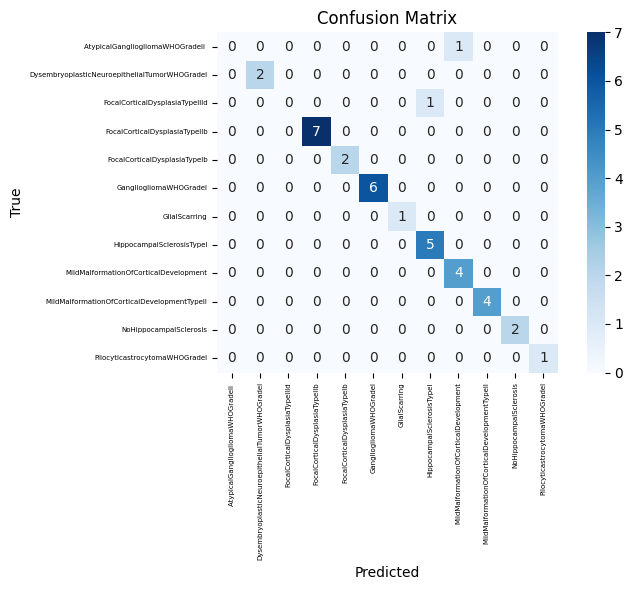


 Evaluating Fold 5 Model
2/2 [==============================] - 2s 37ms/step
Test Acc: 0.9444

Classification Report:
                                               precision    recall  f1-score   support

             AtypicalGangliogliomaWHOGradeIi        0.00      0.00      0.00         1
DysembryoplasticNeuroepithelialTumorWHOGradeI       1.00      1.00      1.00         2
               FocalCorticalDysplasiaTypeIIId       0.00      0.00      0.00         1
                FocalCorticalDysplasiaTypeIIb       1.00      1.00      1.00         7
                 FocalCorticalDysplasiaTypeIb       1.00      1.00      1.00         2
                       GangliogliomaWHOGradeI       1.00      1.00      1.00         6
                                GlialScarring       1.00      1.00      1.00         1
                    HippocampalSclerosisTypeI       0.83      1.00      0.91         5
        MildMalformationOfCorticalDevelopment       0.80      1.00      0.89         4
  MildMalf

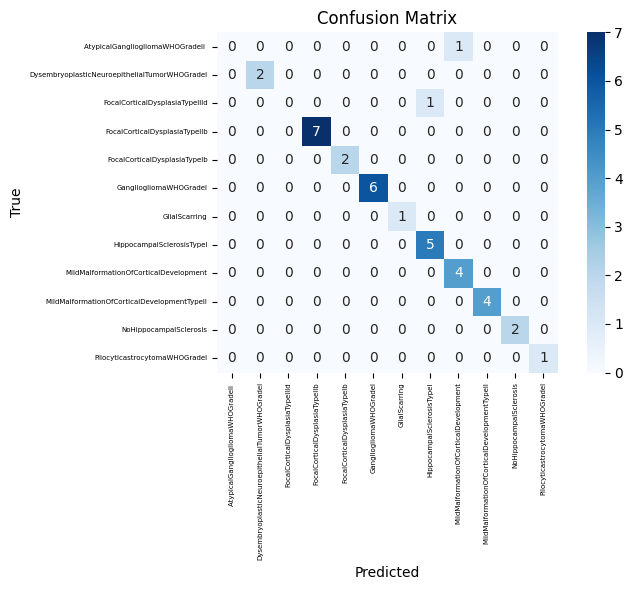

In [40]:
for fold in range(1, 6):
    print(f"\n Evaluating Fold {fold} Model")
    
    model = build_model()
    model.load_weights(f"ontology_fold_{fold}.h5")

    evaluate_model(model=model,test_df=test_ontology, class_names=class_names)

In [41]:
preds = []
for fold in range(1, 6):
    
    model = build_model()
    model.load_weights(f"ontology_fold_{fold}.h5")

    pred = prediction(model=model,test_df=test_ontology)
    preds.append(pred) 

avg_preds = np.mean(np.array(preds), axis=0)
y_pred = np.argmax(avg_preds, axis=1)

2/2 [==============================] - 2s 43ms/step


Test Acc: 0.9444

Classification Report:
                                               precision    recall  f1-score   support

             AtypicalGangliogliomaWHOGradeIi        0.00      0.00      0.00         1
DysembryoplasticNeuroepithelialTumorWHOGradeI       1.00      1.00      1.00         2
               FocalCorticalDysplasiaTypeIIId       0.00      0.00      0.00         1
                FocalCorticalDysplasiaTypeIIb       1.00      1.00      1.00         7
                 FocalCorticalDysplasiaTypeIb       0.67      1.00      0.80         2
                       GangliogliomaWHOGradeI       1.00      1.00      1.00         6
                                GlialScarring       1.00      1.00      1.00         1
                    HippocampalSclerosisTypeI       1.00      1.00      1.00         5
        MildMalformationOfCorticalDevelopment       0.80      1.00      0.89         4
  MildMalformationOfCorticalDevelopmentTypeII       1.00      1.00      1.00         4
 

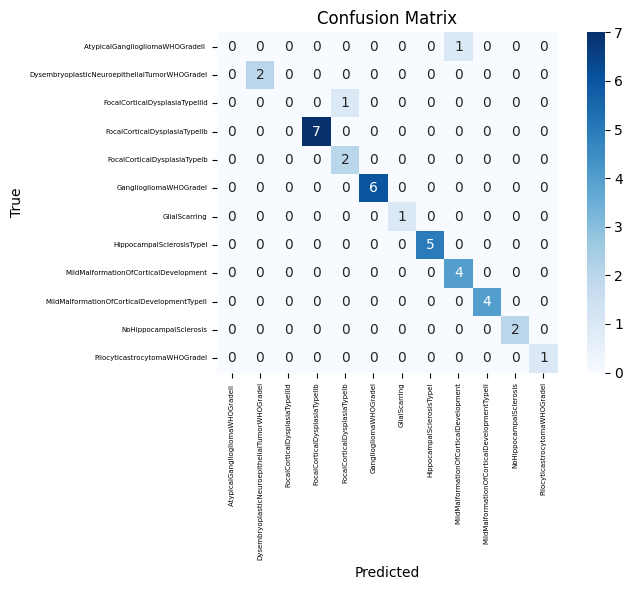

In [42]:
y_true = test_ontology['label'].values

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test Acc: {acc:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            square=True, xticklabels=class_names, yticklabels=class_names)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5) 
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [43]:
preds = []
for fold in range(1, 6):
    
    model = build_model()
    model.load_weights(f"ontology_fold_{fold}.h5")

    pred = prediction(model=model,test_df=train_val_ontology)
    preds.append(pred) 

avg_preds = np.mean(np.array(preds), axis=0)
y_pred = np.argmax(avg_preds, axis=1)

5/5 [==============================] - 3s 179ms/step


Test Acc: 0.9366

Classification Report:
                                               precision    recall  f1-score   support

             AtypicalGangliogliomaWHOGradeIi        1.00      0.83      0.91         6
DysembryoplasticNeuroepithelialTumorWHOGradeI       1.00      1.00      1.00         8
               FocalCorticalDysplasiaTypeIIId       1.00      0.83      0.91         6
                FocalCorticalDysplasiaTypeIIb       1.00      0.96      0.98        27
                 FocalCorticalDysplasiaTypeIb       1.00      1.00      1.00         8
                       GangliogliomaWHOGradeI       0.85      1.00      0.92        23
                                GlialScarring       1.00      1.00      1.00         4
                    HippocampalSclerosisTypeI       0.95      1.00      0.98        21
        MildMalformationOfCorticalDevelopment       0.84      1.00      0.91        16
  MildMalformationOfCorticalDevelopmentTypeII       0.91      0.77      0.83        13
 

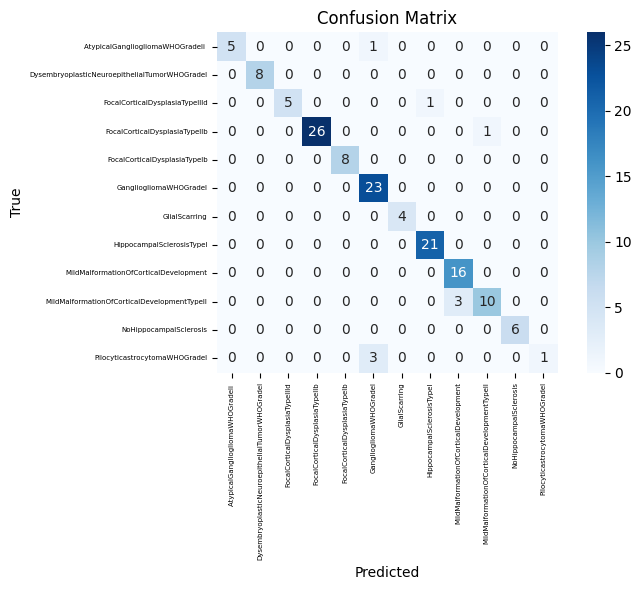

In [44]:
y_true = train_val_ontology['label'].values

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test Acc: {acc:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            square=True, xticklabels=class_names, yticklabels=class_names)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5) 
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()